In [1]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1","cluster_a","cluster_b","cluster_c"]
load_list_dict = dict()
load_list_dict["unv1"] = range(1,11)
load_list_dict["prv1"] = range(1,11)
load_list_dict["cluster_a"] = range(3,31,3)
load_list_dict["cluster_b"] = range(4,41,4)
load_list_dict["cluster_c"] = range(5,51,5)
all_load_list_dict = load_list_dict # have no meaning here, just too lazy to change
# all_load_list_dict = dict()
# all_load_list_dict["unv1"] = range(1,11)
# all_load_list_dict["prv1"] = range(1,11)
# all_load_list_dict["cluster_a"] = range(3,31,3)
# all_load_list_dict["cluster_b"] = [10,30,50]
seed_list = [1,2,3,4,5]
scheme_list = ["leafspine","dringsu2","dringsu3","dringecmp","dringwcmpecmp","dringwcmpsu2","dringfatpaths","dringfhi","dringracke1four","dringracke1","df2su2","df2su3","df2su4","df2augalg","rrgsu2","rrgsu3"]


In [ ]:
import os

cm_topickle_list = []
sumfile = "fct_summary.txt"
datadict = dict()
with open(sumfile,'a') as fw:
    for i in cm_topickle_list:
        for j in scheme_list:
            if os.path.exists(f"{i}/outfiles/{j}_load{load_list_dict[i][0]}_seed{seed_list[0]}.out"):
                for load in all_load_list_dict[i]:
                    for seed in seed_list:
                        outfile = f"{i}/outfiles/{j}_load{load}_seed{seed}.out"
                        durationlist = list()
                        sizelist = list()
                        startlist = list()
                        with open(outfile,'r') as fr:
                            lines = fr.readlines()
                            for line in lines:
                                tokens = line.split()
                                if tokens[0] == "FCT":
                                    durationlist.append(float(tokens[2]))
                                    sizelist.append(int(tokens[1]))
                                    startlist.append(float(tokens[3]))
                        durationlist.sort()
                        datadict[outfile] = [durationlist,sizelist,startlist]
                        
                        fw.write(f"{outfile}\t{sum(durationlist)/len(durationlist)}\t{durationlist[int(len(durationlist)*0.5)]}\t{durationlist[int(len(durationlist)*0.99)]}\t{durationlist[int(len(durationlist)*0.9999)]}\n")

            # intentional -- repeatedly save current progress
            with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_main_{i}.pickle', 'wb') as handle:
                pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [2]:
import os

scheme_topickle_list = ["dringwcmpecmp"]
sumfile = "fct_summary.txt"
datadict = dict()
with open(sumfile,'a') as fw:
    for j in scheme_topickle_list:
        for i in cm_list:
            if os.path.exists(f"{i}/outfiles/{j}_load{load_list_dict[i][0]}_seed{seed_list[0]}.out"):
                for load in all_load_list_dict[i]:
                    for seed in seed_list:
                        outfile = f"{i}/outfiles/{j}_load{load}_seed{seed}.out"
                        durationlist = list()
                        sizelist = list()
                        startlist = list()
                        with open(outfile,'r') as fr:
                            lines = fr.readlines()
                            for line in lines:
                                tokens = line.split()
                                if tokens[0] == "FCT":
                                    durationlist.append(float(tokens[2]))
                                    sizelist.append(int(tokens[1]))
                                    startlist.append(float(tokens[3]))
                        durationlist.sort()
                        datadict[outfile] = [durationlist,sizelist,startlist]
                        
                        fw.write(f"{outfile}\t{sum(durationlist)/len(durationlist)}\t{durationlist[int(len(durationlist)*0.5)]}\t{durationlist[int(len(durationlist)*0.99)]}\t{durationlist[int(len(durationlist)*0.9999)]}\n")

                # intentional -- repeatedly save current progress
                with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_main_{j}.pickle', 'wb') as handle:
                    pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

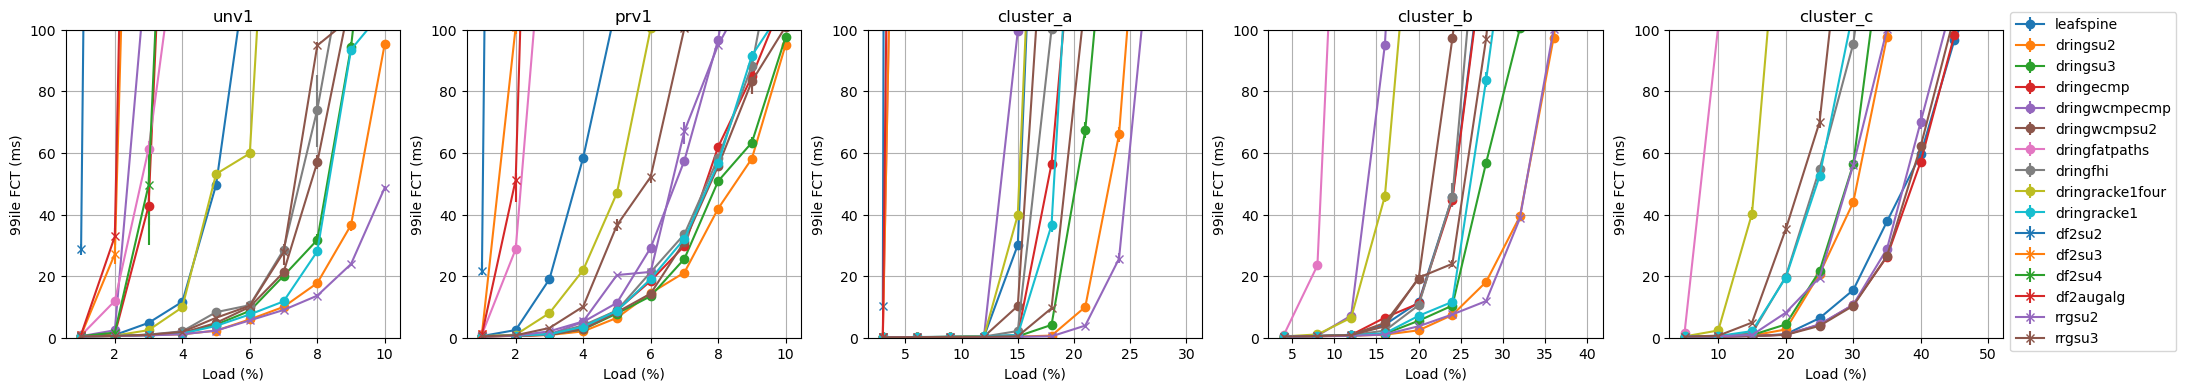

In [3]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99


markerlist = ['o','x']
nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        if f"{cm}/outfiles/{scheme}_load{load_list_dict[cm][0]}_seed{seed_list[0]}.out" in plotdatadict[cm]:
            fct_list = list()
            for load in load_list_dict[cm]:
                fct_list_allseeds = list()
                for seed in seed_list:
                    outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                    p99 = plotdatadict[cm][outfile]
                    fct_list_allseeds.append(p99)
                fct_list.append(fct_list_allseeds)
            if ic==0:
                axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], label=scheme)
            else:
                axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10])
        else:
            if ic==0:
                axs[ic].errorbar([],[], yerr=[], marker=markerlist[isc//10], label=scheme)
            else:
                axs[ic].errorbar([],[], yerr=[], marker=markerlist[isc//10])
    axs[ic].set_xlabel("Load (%)")
    axs[ic].set_ylabel("99ile FCT (ms)")
    axs[ic].set_ylim(0,100)
    axs[ic].set_title(cm)
    axs[ic].grid(True)
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

In [ ]:
# sumfile = "fct_summary_adjusted.txt"
# with open(sumfile,'w') as fw:
#     for i in cm_list:
#         for j in scheme_list:
#             for load in load_list:
#                 if  j=="leafspine":
#                     cmfile = f"{i}/cmfiles/{j}_load{load}.cm"
#                 elif j.startswith("dring"):
#                     cmfile = f"{i}/cmfiles/dring_load{load}.cm"
#                 with open(cmfile, "r") as fr:
#                     num_lines = sum(1 for _ in fr)
#                 for seed in seed_list:
#                     outfile \= f"{i}/outfiles/{j}_load{load}_seed{seed}.out"
#                     durationlist = list()
#                     sizelist = list()
#                     startlist = list()
#                     with open(outfile,'r') as fr:
#                         lines = fr.readlines()
#                         for line in lines:
#                             tokens = line.split()
#                             if tokens[0] == "FCT":
#                                 durationlist.append(float(tokens[2]))
#                                 sizelist.append(int(tokens[1]))
#                                 startlist.append(float(tokens[3]))
#                     durationlist.sort()
#                     pad = num_lines - len(durationlist)
#                     # print(f"{outfile} has {pad} padded flows")
#                     datadict[outfile] = [durationlist,sizelist,startlist,pad]
                    
#                     adjusted_durationlist = durationlist + [100]*pad
#                     fw.write(f"{outfile}\t{sum(adjusted_durationlist)/len(adjusted_durationlist)}\t{adjusted_durationlist[int(len(adjusted_durationlist)*0.5)]}\t{adjusted_durationlist[int(len(adjusted_durationlist)*0.99)]}\t{adjusted_durationlist[int(len(adjusted_durationlist)*0.9999)]}\n")

# with open(f'{homedir}az6922_data/starfish_nsdi26fall_pickle/eval_main.pickle', 'wb') as handle:
#     pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# datadict = dict()
# for cm in cm_list:
#     print(f"Loading pickle for {cm}")
#     with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_main_{cm}.pickle', "rb") as f:
#         datadict[cm] = pickle.load(f)

Loading pickle for unv1
Loading pickle for prv1
Loading pickle for cluster_a


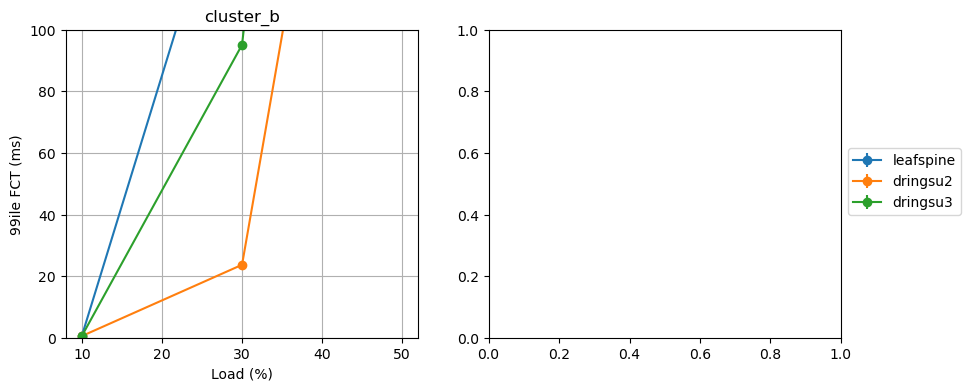

In [ ]:
# # draft plot results
# import matplotlib.pyplot as plt
# import numpy as np

# markerlist = ['o','x']
# nr = 1
# nc = len(cm_list)
# fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
# for ic,cm in enumerate(cm_list):
#     for isc,scheme in enumerate(scheme_list):
#         if f"{cm}/outfiles/{scheme}_load{load_list_dict[cm][0]}_seed{seed_list[0]}.out" in datadict[cm]:
#             fct_list = list()
#             for load in load_list_dict[cm]:
#                 fct_list_allseeds = list()
#                 for seed in seed_list:
#                     outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
#                     durationlist = datadict[cm][outfile][0]
#                     fct_list_allseeds.append(durationlist[int(len(durationlist)*0.99)])
#                 fct_list.append(fct_list_allseeds)
#             if ic==0:
#                 axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], label=scheme)
#             else:
#                 axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10])
#         else:
#             if ic==0:
#                 axs[ic].errorbar([],[], yerr=[], marker=markerlist[isc//10], label=scheme)
#             else:
#                 axs[ic].errorbar([],[], yerr=[], marker=markerlist[isc//10])
#     axs[ic].set_xlabel("Load (%)")
#     axs[ic].set_ylabel("99ile FCT (ms)")
#     axs[ic].set_ylim(0,100)
#     axs[ic].set_title(cm)
#     axs[ic].grid(True)
# fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

# # for ic,cm in enumerate(cm_list):
# #     for scheme in scheme_list:
# #         for load in load_list:
# #             for seed in seed_list:
# #                 outfile = f"{i}/outfiles/{j}_load{load}_seed{seed}.out"
# #                 durationlist = datadict[outfile][0]
# #                 cdf = np.arange(1, len(durationlist)+1) / len(durationlist)
# #                 axs[ic].plot(durationlist, cdf, label=f"{j} {load}%")
# #     axs[ic].set_xlim(0,10)
# #     axs[ic].set_ylim(0.8,1)
# #     axs[ic].set_xlabel("FCT")
# #     axs[ic].set_ylabel("CDF")
# #     axs[ic].set_title(cm)
# #     axs[ic].grid(True)
# # plt.legend()